In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
path

'/kaggle/input/xapi-edu-data'

In [4]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    data_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file)
    print(f"Loaded '{csv_files[0]}' into DataFrame.")
    display(df.head())
else:
    print("No CSV files found in the directory.")

Loaded 'xAPI-Edu-Data.csv' into DataFrame.


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [5]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

EDA

## Exploratory Data Analysis (EDA) - Visualizations

To perform meaningful visualizations, especially for categorical features, I will reload the original dataset from the file before any one-hot encoding was applied.

In [7]:
# Reload the original DataFrame to visualize features before one-hot encoding
df_original = pd.read_csv(data_file)
df_original.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


### 1. Distribution of Target Variable ('Class')

Let's visualize the distribution of the target variable `Class` (student performance levels: L, M, H) using a count plot.

/tmp/ipykernel_3226/2149178549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df_original, palette='viridis')


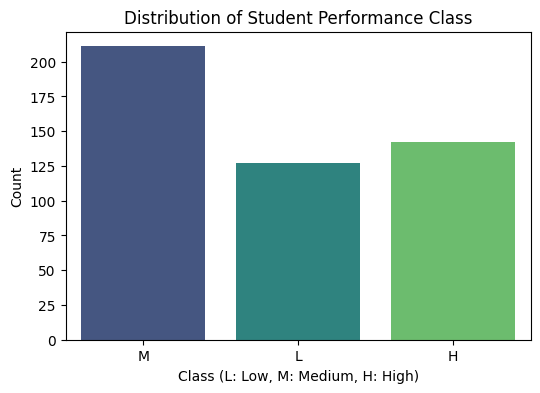

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_original, palette='viridis')
plt.title('Distribution of Student Performance Class')
plt.xlabel('Class (L: Low, M: Medium, H: High)')
plt.ylabel('Count')
plt.show()

### 2. Distribution of Numerical Features

Let's examine the distribution of numerical features such as `raisedhands`, `VisITedResources`, `AnnouncementsView`, and `Discussion` using histograms.

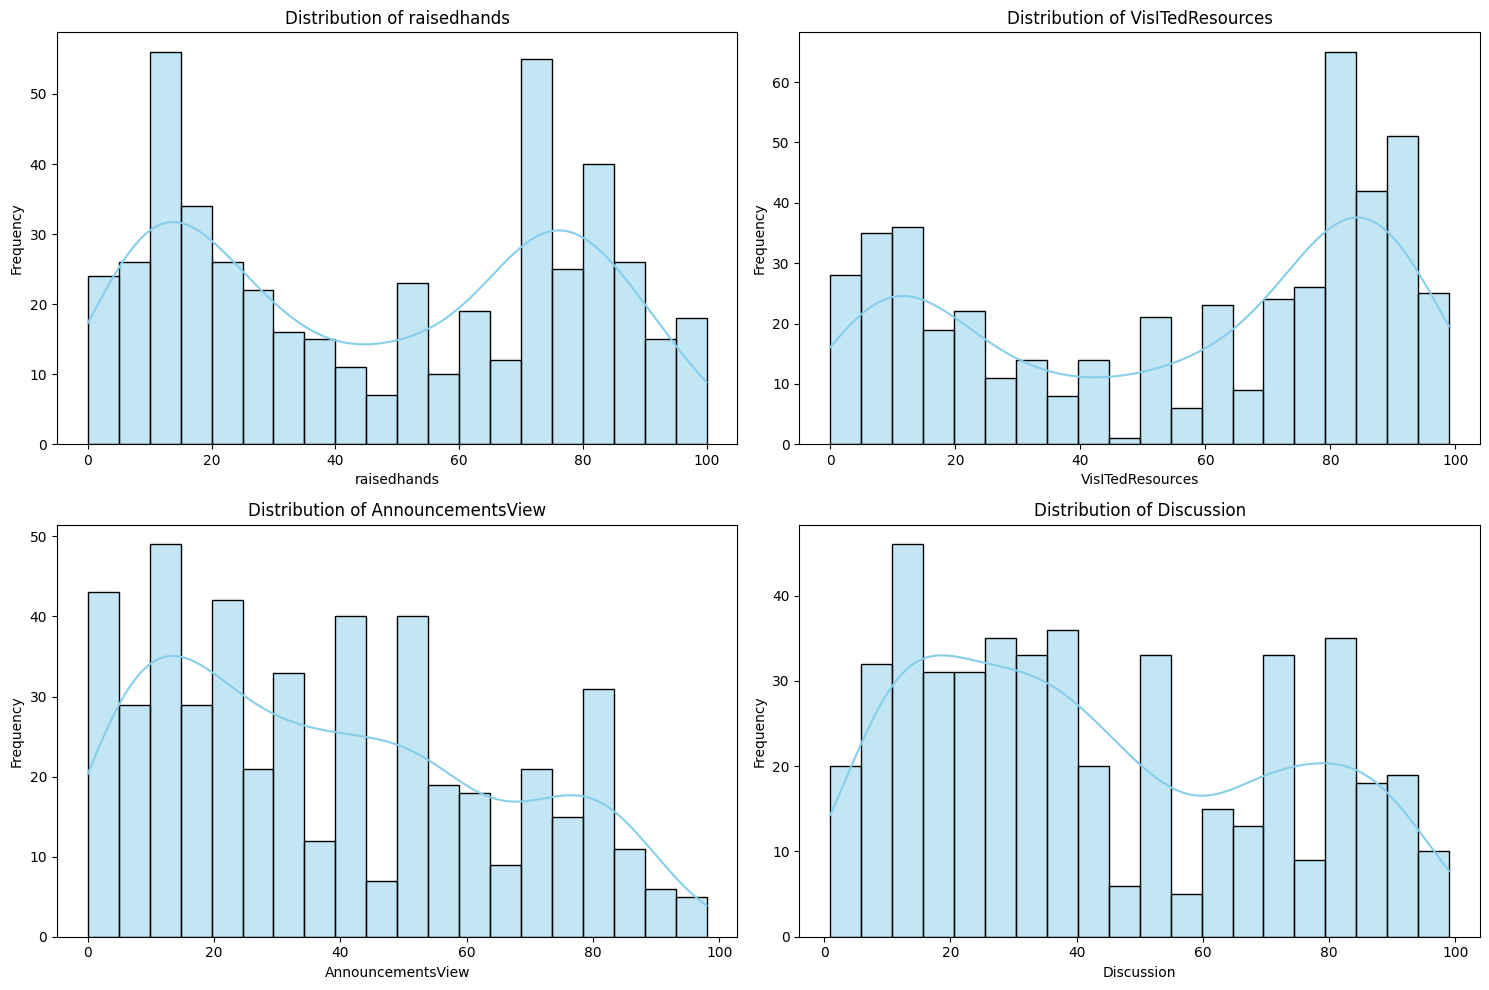

In [9]:
numerical_features = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_original[feature], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3. Distribution of Key Categorical Features

Let's visualize the distribution of some important categorical features like `gender`, `NationalITy`, `Topic`, and `StudentAbsenceDays`.

/tmp/ipykernel_3226/1564621592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df_original, palette='deep', order=df_original[feature].value_counts().index)
/tmp/ipykernel_3226/1564621592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df_original, palette='deep', order=df_original[feature].value_counts().index)
/tmp/ipykernel_3226/1564621592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df_original, palette='deep', order=df_original[feature].value_counts().index)
/tmp/ipyke

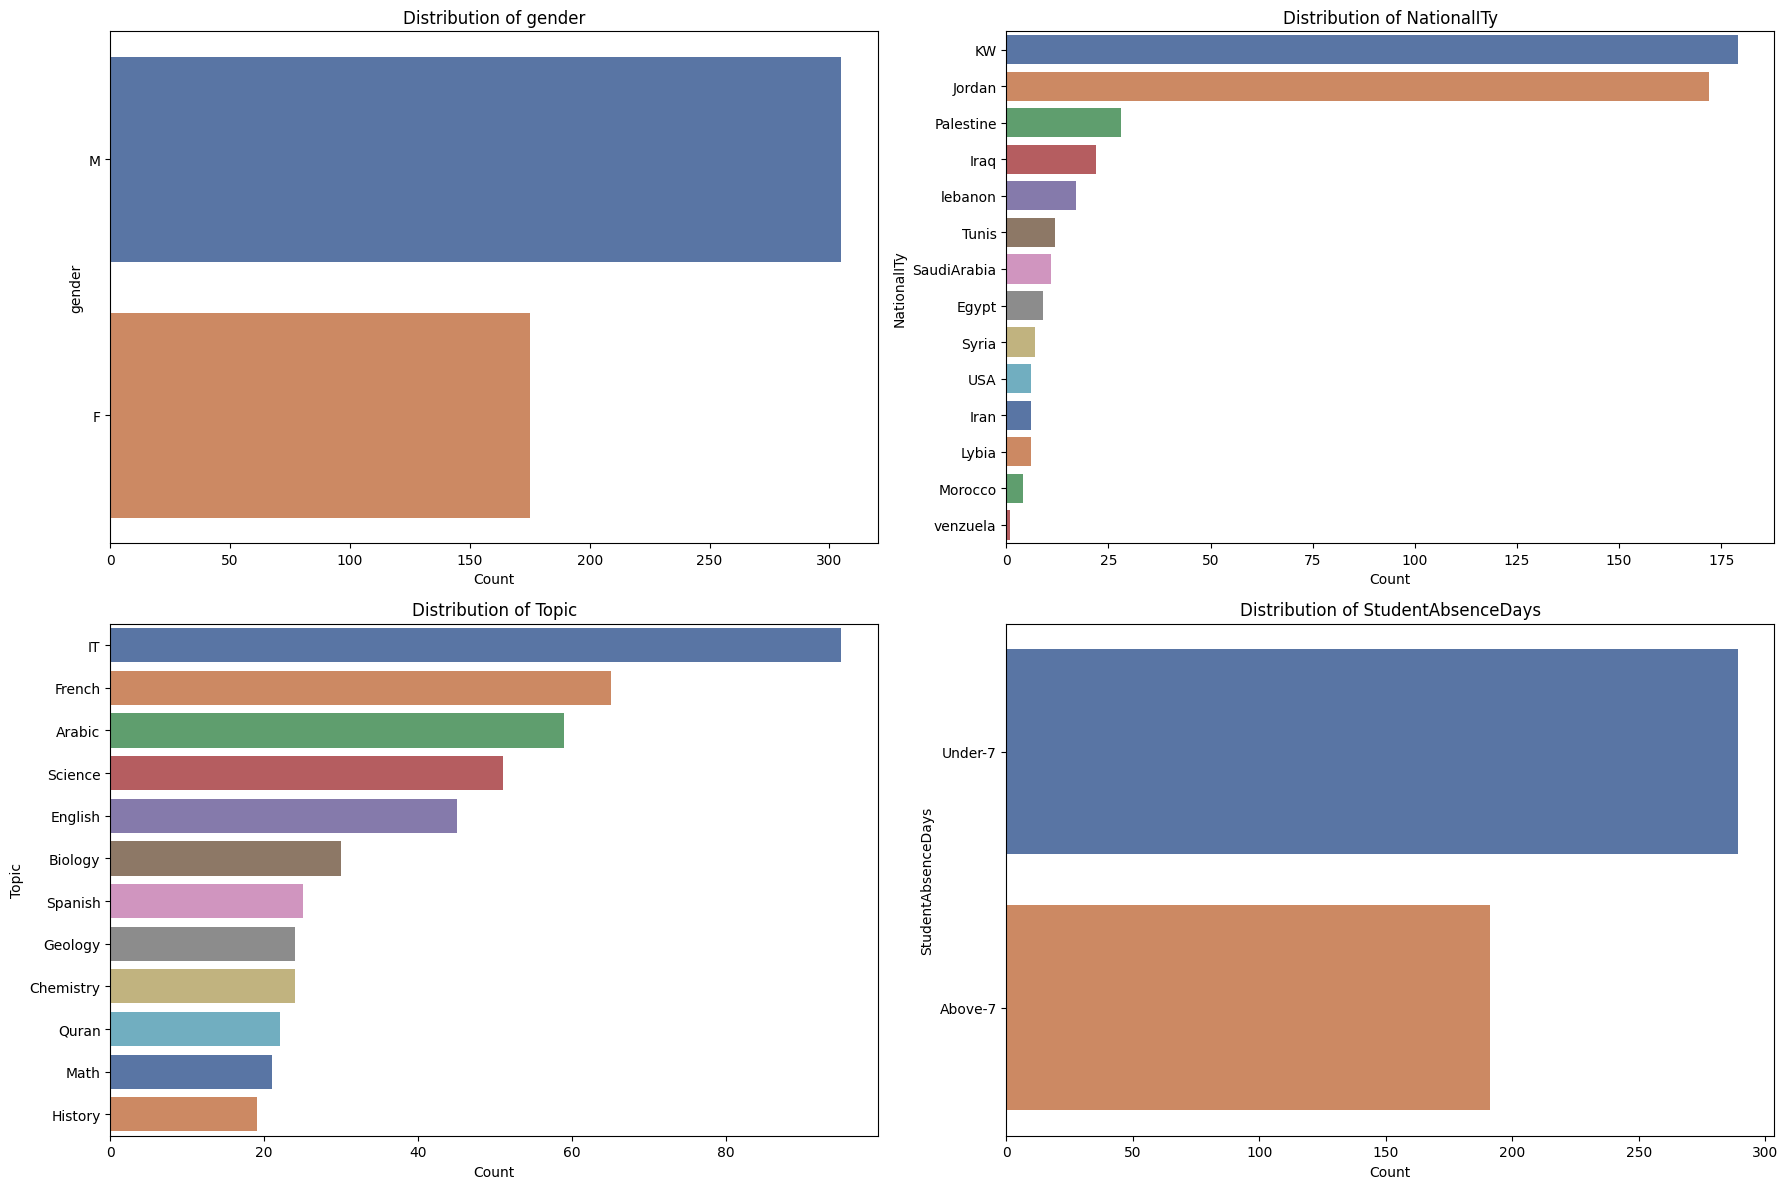

In [10]:
categorical_features_to_plot = ['gender', 'NationalITy', 'Topic', 'StudentAbsenceDays']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(categorical_features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.countplot(y=feature, data=df_original, palette='deep', order=df_original[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Count')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### 4. Relationship between Features and 'Class'

Let's explore how some numerical and categorical features relate to the `Class` (target variable).

#### Numerical Features vs. Class (Box Plots)

/tmp/ipykernel_3226/60317675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_original, palette='coolwarm', order=['L', 'M', 'H'])
/tmp/ipykernel_3226/60317675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_original, palette='coolwarm', order=['L', 'M', 'H'])
/tmp/ipykernel_3226/60317675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_original, palette='coolwarm', order=['L', 'M', 'H'])
/tmp/ipykernel_3226/60317675.py:4: FutureWarning: 

Pas

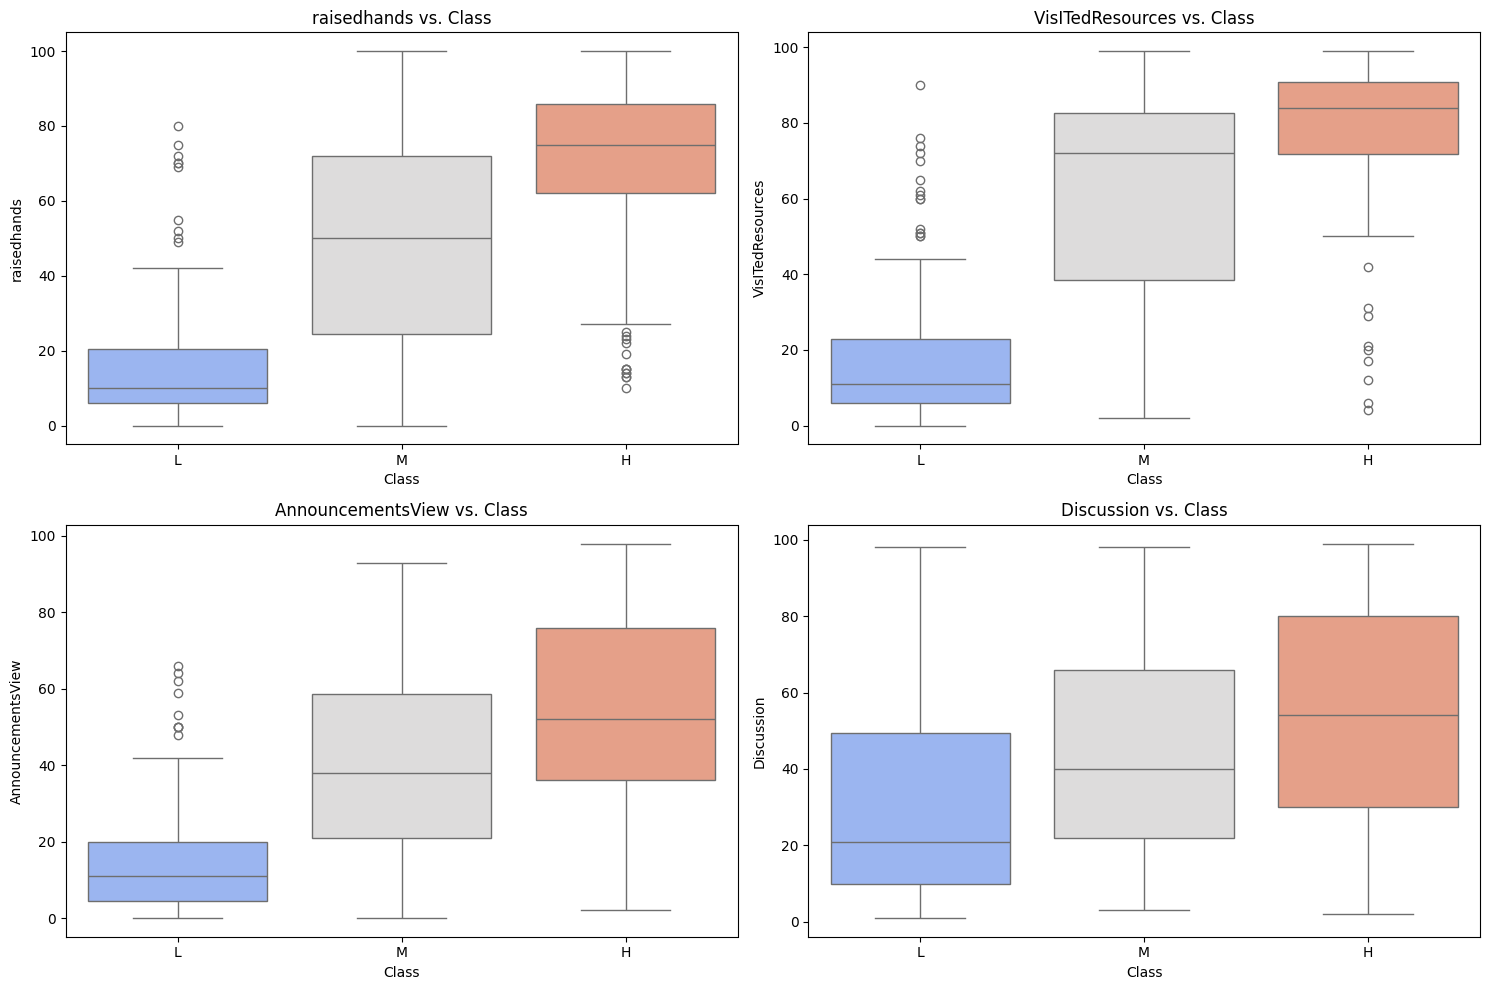

In [11]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='Class', y=feature, data=df_original, palette='coolwarm', order=['L', 'M', 'H'])
    plt.title(f'{feature} vs. Class')
    plt.xlabel('Class')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

#### Categorical Features vs. Class (Count Plots with Hue)

We can use count plots with `Class` as hue to see the distribution of `Class` within each category.

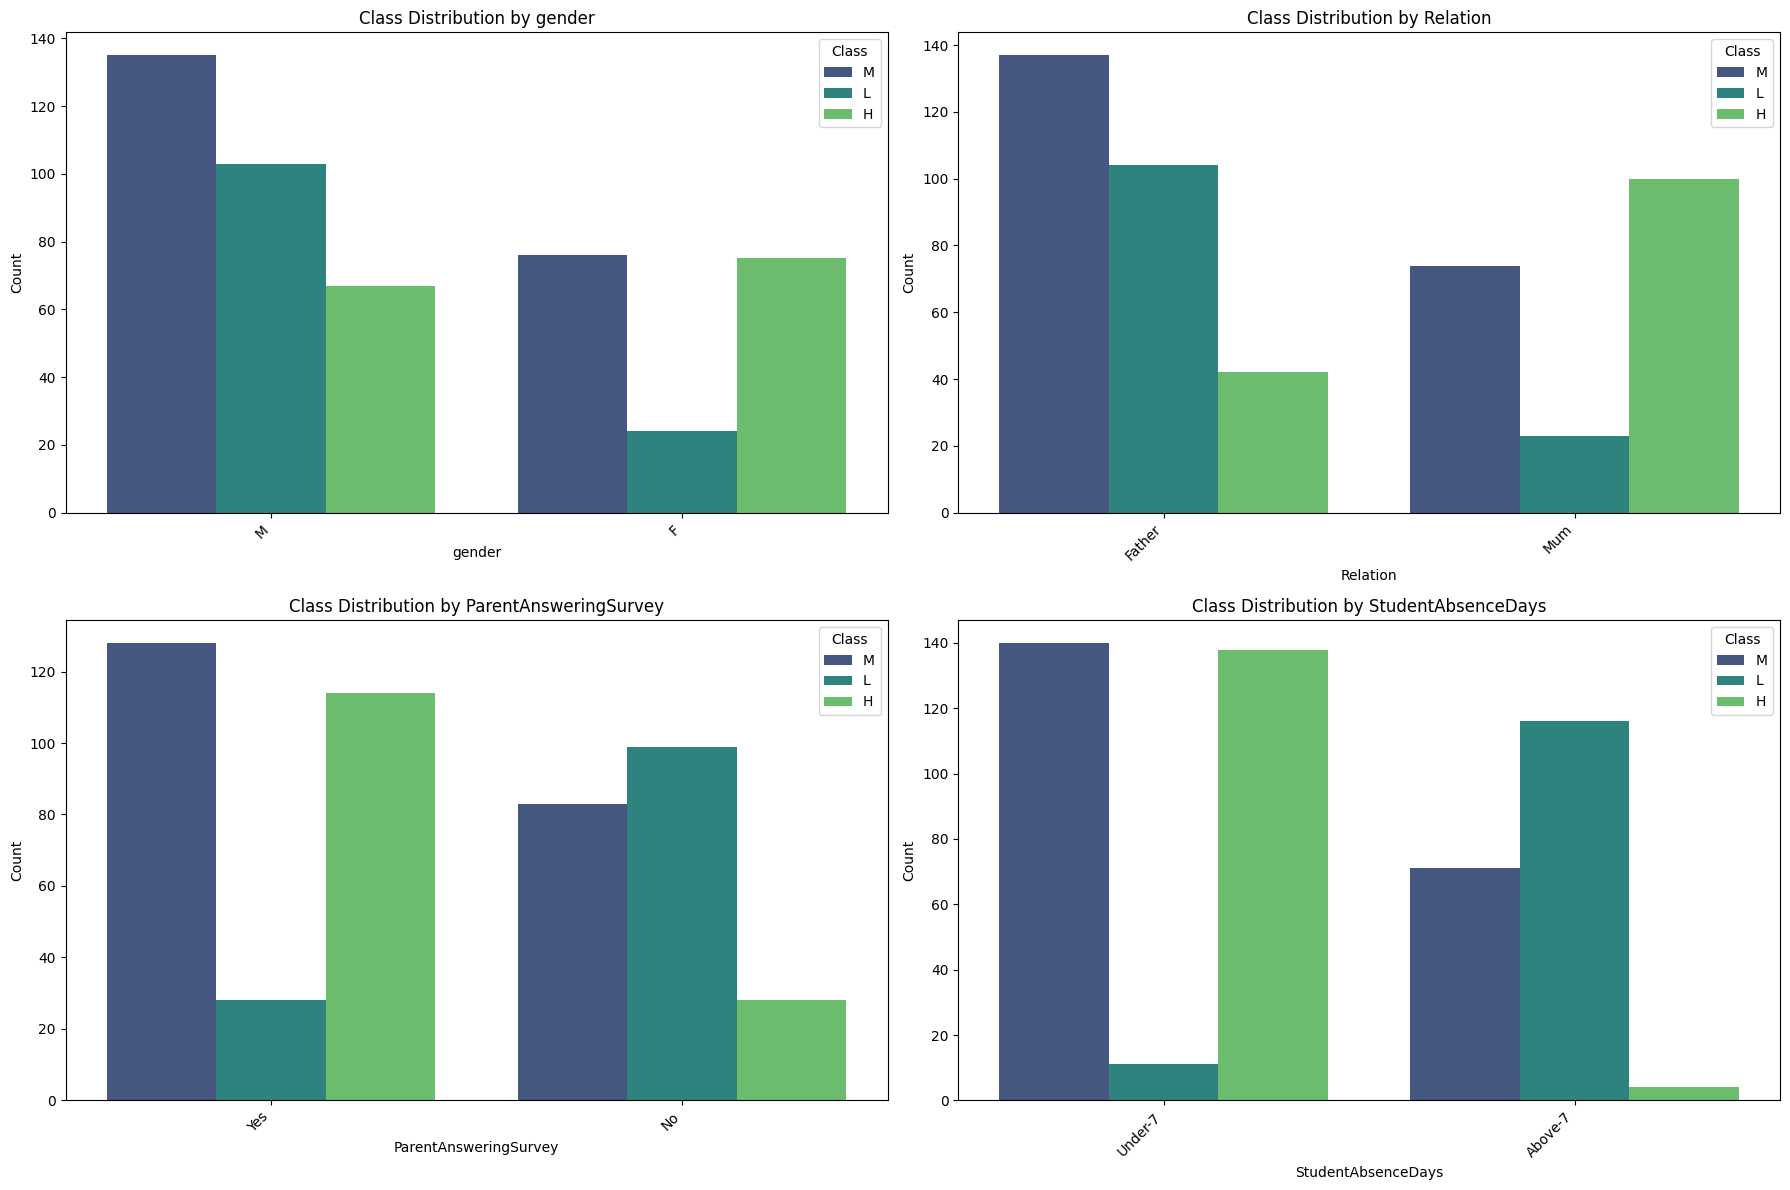

In [12]:
categorical_features_for_class_relation = ['gender', 'Relation', 'ParentAnsweringSurvey', 'StudentAbsenceDays']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(categorical_features_for_class_relation):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='Class', data=df_original, palette='viridis', order=df_original[feature].value_counts().index)
    plt.title(f'Class Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Class')
plt.tight_layout()
plt.show()

### 5. Correlation Matrix for Numerical Features

Let's visualize the correlation between the numerical features.

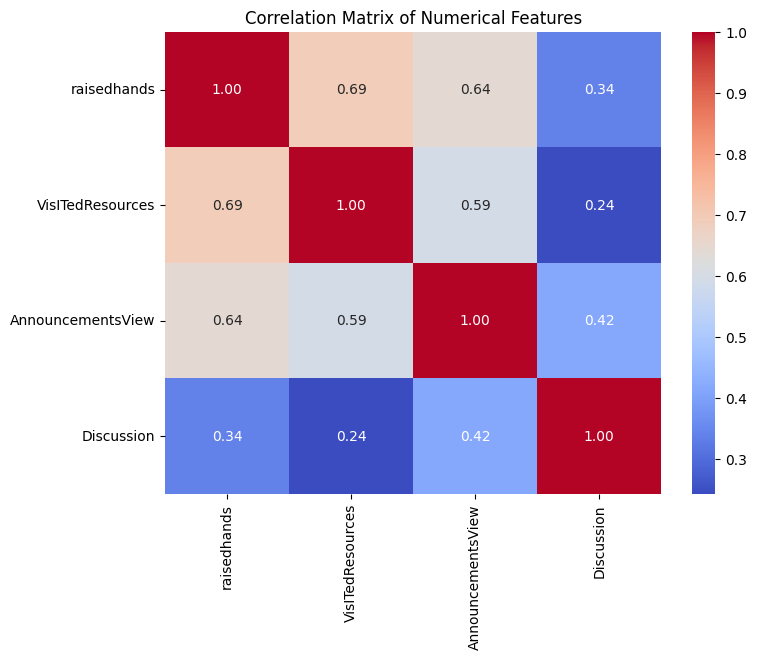

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_original[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [14]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [15]:
# target variable is class
df['Class'].value_counts()

,count
Class,
M,211
H,142
L,127


In [16]:
df['Class'].unique()

array(['M', 'L', 'H'], dtype=object)

<Axes: xlabel='Class', ylabel='count'>

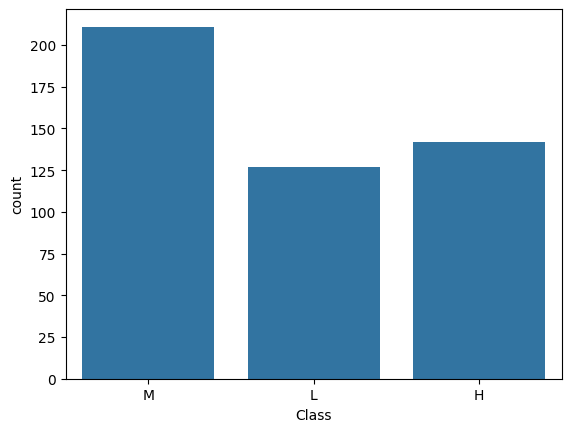

In [17]:
# data type is classification -> class imbalance
sns.countplot(x=df['Class'])


In [18]:
# encoding all the object type columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Class')

df=pd.get_dummies(df,columns=cat_cols)

In [19]:
df['Class'] = df['Class'].map({"M":0,'L':1,'H':2})

Model Building


KNN CLASSIFICATION

In [20]:
'''KNN is an distance based algorithm and because of this we are going to perform standard scalling'''


'KNN is an distance based algorithm and because of this we are going to perform standard scalling'

In [21]:
X = df.drop('Class', axis=1)
y = df['Class']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [23]:
# standard scaling -> to avoid data leacking
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [25]:
score = [] #we are storing accuracy for each k value (1to20)
for k in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train) #training
  y_pred = knn.predict(X_test) #prediction

  accuracy = accuracy_score(y_test, y_pred) #accuracy
  score.append(accuracy)

In [26]:
score

[0.6875,
 0.6666666666666666,
 0.6145833333333334,
 0.5729166666666666,
 0.5729166666666666,
 0.6145833333333334,
 0.5625,
 0.6145833333333334,
 0.65625,
 0.59375,
 0.6354166666666666,
 0.5729166666666666,
 0.6458333333333334,
 0.5416666666666666,
 0.6145833333333334,
 0.5520833333333334,
 0.59375,
 0.6041666666666666,
 0.5520833333333334,
 0.5520833333333334]

In [27]:
# model build
knn = KNeighborsClassifier(n_neighbors=16)
knn.fit(X_train, y_train) #training KNN model

KNeighborsClassifier(n_neighbors=16)

In [28]:
# train
y_pred_train = knn.predict(X_train)

In [29]:
# predict
y_pred = knn.predict(X_test)

In [30]:
# evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.5520833333333334
[[26 11 11]
 [ 6 19  1]
 [14  0  8]]


In [31]:
# testing
accuracy_score(y_test,y_pred)

0.5520833333333334

In [32]:
# training
accuracy_score(y_train,y_pred_train)

0.6822916666666666

<Axes: >

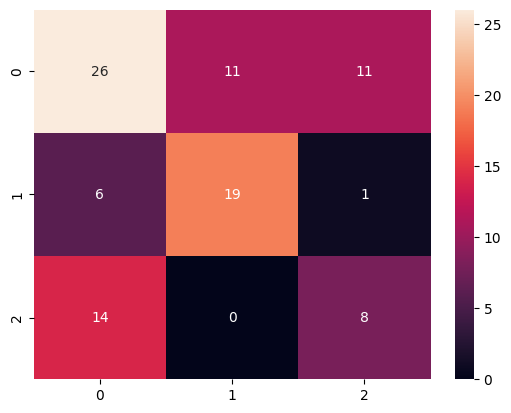

In [33]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [34]:
import joblib
joblib.dump(knn, 'knn_model.pkl')

['knn_model.pkl']